# E-commerce Sales Export Analysis

Онлайн-продажи за 2019-2020 годы

**Цель:** провести разведочный анализ (EDA) для поиска аномалий и структуры данных.

###  Exploratory Data Analysis

- Загрузка данных, изучение общей структуры данных

In [1]:
import pandas as pd

In [2]:
# Загрузка данных

In [3]:
df.head()

,country,order_value_EUR,cost,date,category,customer_name,sales_manager,sales_rep,device_type,order_id
0,Sweden,"17,524.02",14122.61,2/12/2020,Books,Goldner-Dibbert,Maxie Marrow,Madelon Bront,Mobile,70-0511466
1,Finland,"116,563.40",92807.78,9/26/2019,Games,Hilll-Vandervort,Hube Corey,Wat Bowkley,Mobile,28-6585323
2,Portugal,"296,465.56",257480.34,7/11/2019,Clothing,Larkin-Collier,Celine Tumasian,Smitty Culverhouse,PC,58-7703341
3,Portugal,"74,532.02",59752.32,4/2/2020,Beauty,Hessel-Stiedemann,Celine Tumasian,Aurelie Wren,PC,14-6700183
4,Spain,"178,763.42",146621.76,12/22/2019,Games,Johns and Sons,Emalia Dinse,Bertha Walbrook,Tablet,15-8765160


In [4]:
# Размерность 
df.shape

(1000, 10)

In [5]:
# Информация о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            1000 non-null   object 
 1    order_value_EUR   1000 non-null   object 
 2    cost              1000 non-null   float64
 3   date               1000 non-null   object 
 4   category           1000 non-null   object 
 5   customer_name      1000 non-null   object 
 6   sales_manager      1000 non-null   object 
 7   sales_rep          1000 non-null   object 
 8   device_type        1000 non-null   object 
 9   order_id           1000 non-null   object 
dtypes: float64(1), object(9)
memory usage: 78.2+ KB


In [6]:
# Названия столбцов
df.columns

Index(['country', ' order_value_EUR ', ' cost ', 'date', 'category',
       'customer_name', 'sales_manager', 'sales_rep', 'device_type',
       'order_id'],
      dtype='object')

- Очистка данных

In [7]:
# Проверка на наличие пропусков
df.isnull().sum()

country              0
 order_value_EUR     0
 cost                0
date                 0
category             0
customer_name        0
sales_manager        0
sales_rep            0
device_type          0
order_id             0
dtype: int64

In [8]:
# Переименуем колонки, убрав лишние пробелы
df = df.rename(columns={' cost ': 'cost', ' order_value_EUR ':'order_value_eur'})

In [9]:
# Изменение типа данных для столбца date с object на datetime
df['date'] = pd.to_datetime(df['date'])

In [10]:
# Изменение типа данных для столбца order_value_eur с object на float
df['order_value_eur'] = df['order_value_eur'].str.replace(',', '') # удаляем запятую
df['order_value_eur'] = pd.to_numeric(df['order_value_eur'])  

In [11]:
# Поиск дубликатов
df.duplicated().sum()

0

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   country          1000 non-null   object        
 1   order_value_eur  1000 non-null   float64       
 2   cost             1000 non-null   float64       
 3   date             1000 non-null   datetime64[ns]
 4   category         1000 non-null   object        
 5   customer_name    1000 non-null   object        
 6   sales_manager    1000 non-null   object        
 7   sales_rep        1000 non-null   object        
 8   device_type      1000 non-null   object        
 9   order_id         1000 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 78.2+ KB


- Предварительный анализ данных

In [13]:
# Добавим вычисляемые поля
df['profit'] = df['order_value_eur'] - df['cost']
df['profit_margin'] = (df['profit'] / df['order_value_eur']) * 100
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month

In [14]:
# Сводка по числовым признакам
df.describe()  

,order_value_eur,cost,date,profit,profit_margin,year,month
count,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000.00000,1000.000000
mean,113361.738710,94369.310990,2020-01-01 05:41:16.799999744,18992.427720,16.745170,2019.51000,6.418000
min,15100.570000,12113.680000,2019-01-02 00:00:00,2073.610000,11.999996,2019.00000,1.000000
25%,65310.862500,54247.957500,2019-06-30 18:00:00,10746.402500,14.340001,2019.00000,3.000000
50%,105419.425000,87094.760000,2020-01-05 00:00:00,17331.830000,16.984991,2020.00000,6.000000
75%,151192.642500,125570.837500,2020-06-26 00:00:00,25205.325000,19.045001,2020.00000,9.000000
max,383996.760000,304701.430000,2020-12-30 00:00:00,79295.330000,21.000003,2020.00000,12.000000
std,61775.335675,51540.020934,NaN,10917.650434,2.670944,0.50015,3.453578


In [15]:
# Сводка по категориальным признакам
df.describe(include=['object'])

,country,category,customer_name,sales_manager,sales_rep,device_type,order_id
count,1000,1000,1000,1000,1000,1000,1000
unique,15,10,75,15,35,3,1000
top,Portugal,Clothing,Johns and Sons,Celine Tumasian,Amelina Piscopiello,PC,70-0511466
freq,239,155,142,239,56,785,1


In [16]:
# Уникальные значения в каждом столбце
df.nunique()

country              15
order_value_eur    1000
cost               1000
date                536
category             10
customer_name        75
sales_manager        15
sales_rep            35
device_type           3
order_id           1000
profit             1000
profit_margin      1000
year                  2
month                12
dtype: int64

In [17]:
# Общая выручка
total_sales = df['order_value_eur'].sum()
total_sales.round(2)

113361738.71

In [18]:
# Общая стоимость товаров
total_cost = df['cost'].sum()
total_cost.round(2)

94369310.99

In [19]:
# Общая чистая прибыль
total_profit = df['profit'].sum()
total_profit.round(2)

18992427.72

In [20]:
# Общая маржинальность(%)
sales_margin = ((total_profit) / total_sales ) * 100
sales_margin.round(2)

16.75

**Визуализация данных**

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 0, 'Страна')

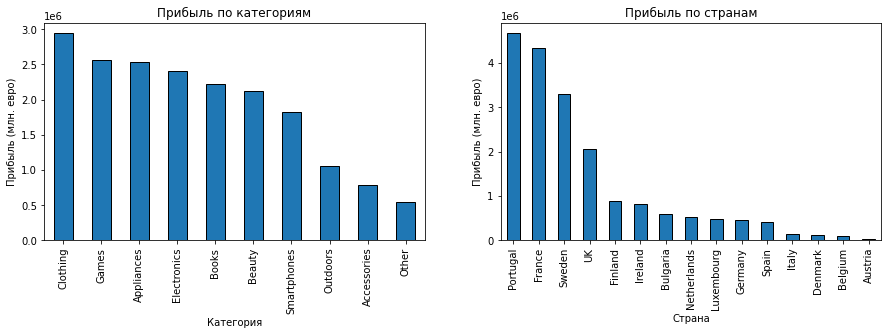

In [36]:
# Распределение прибыли по категориям товаров и странам
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

df.groupby(['category'])['profit'].sum().sort_values(ascending = False).plot(kind= 'bar', edgecolor = 'black', ax = axes[0])
axes[0].set_title('Прибыль по категориям')
axes[0].set_ylabel('Прибыль (млн. евро)')
axes[0].set_xlabel('Категория')

df.groupby(['country'])['profit'].sum().sort_values(ascending = False).plot(kind= 'bar', edgecolor = 'black', ax = axes[1])
axes[1].set_title('Прибыль по странам')
axes[1].set_ylabel('Прибыль (млн. евро)')
axes[1].set_xlabel('Страна')

Text(0, 0.5, '')

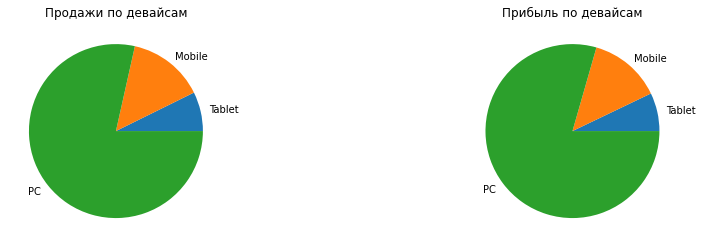

In [32]:
# Распределение продаж и прибыли по девайсам
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

df.groupby('device_type')['order_id'].count().sort_values().plot(kind = 'pie', ax = axes[0])
axes[0].set_title('Продажи по девайсам')
axes[0].set_ylabel('')


df.groupby('device_type')['profit'].sum().sort_values().plot(kind = 'pie',ax = axes[1])
axes[1].set_title('Прибыль по девайсам')
axes[1].set_ylabel('')

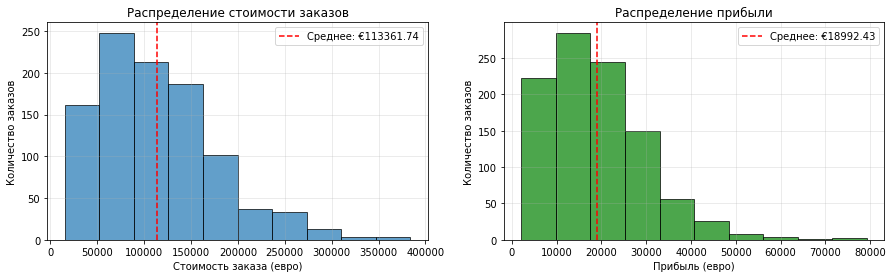

In [25]:
# Распределение стоимости заказов и прибыли
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].hist(df['order_value_eur'], bins=10, edgecolor='black', alpha=0.7)
axes[0].axvline(df['order_value_eur'].mean(), color='red', linestyle='--', label=f'Среднее: €{df["order_value_eur"].mean().round(2)}')
axes[0].set_title('Распределение стоимости заказов')
axes[0].set_xlabel('Стоимость заказа (евро)')
axes[0].set_ylabel('Количество заказов')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].hist(df['profit'], bins=10, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(df['profit'].mean(), color='red', linestyle='--', label=f'Среднее: €{df["profit"].mean().round(2)}')
axes[1].set_title('Распределение прибыли')
axes[1].set_xlabel('Прибыль (евро)')
axes[1].set_ylabel('Количество заказов')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

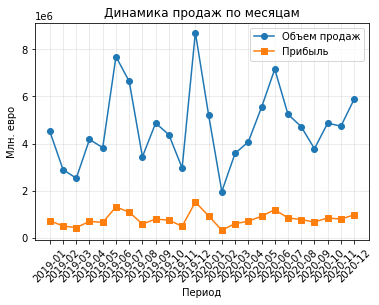

In [26]:
# Динамика продаж по времени
monthly_sales = df.groupby(['year', 'month']).agg({
    'order_value_eur': 'sum',
    'profit': 'sum',
    'order_id': 'count'
}).reset_index()
monthly_sales['period'] = monthly_sales['year'].astype(str) + '-' + monthly_sales['month'].astype(str).str.zfill(2)


plt.plot(monthly_sales['period'].values, monthly_sales['order_value_eur'].values, marker='o', label='Выручка')
plt.plot(monthly_sales['period'].values, monthly_sales['profit'].values, marker='s', label='Прибыль')
plt.title('Динамика продаж по месяцам')
plt.xlabel('Период')
plt.ylabel('Млн. евро')
plt.legend()
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha=0.3)

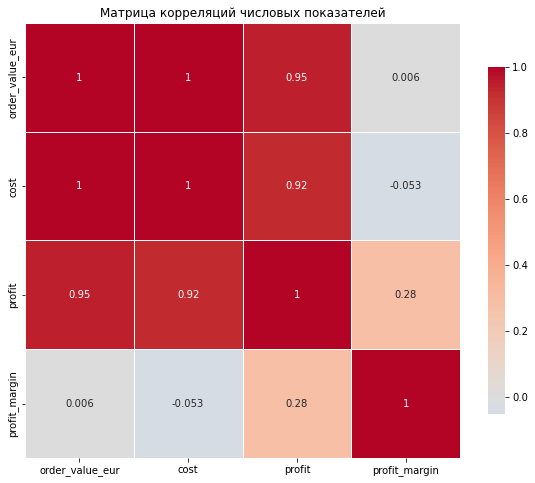


Ключевые выводы по корреляциям:
1. Стоимость и затраты: 0.998
2. Стоимость и прибыль: 0.948


In [57]:
# Корреляционный анализ
# Матрица корреляций
numeric_cols = ['order_value_eur', 'cost', 'profit', 'profit_margin']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций числовых показателей')
plt.show()

print("\nКлючевые выводы по корреляциям:")
print(f"1. Стоимость и затраты: {correlation_matrix.loc['order_value_eur', 'cost']:.3f}")
print(f"2. Стоимость и прибыль: {correlation_matrix.loc['order_value_eur', 'profit']:.3f}")

In [52]:
# Анализ эффективности менеджеров
manager_analysis = df.groupby('sales_manager').agg({
    'order_id': 'count',
    'order_value_eur': 'sum',
    'profit': 'sum',
    'profit_margin': 'mean',
    'customer_name': pd.Series.nunique
}).round(2)

manager_analysis.columns = ['orders_count', 'total_value', 'total_profit', 'total_margin', 'customers_count']

print("Эффективность менеджеров по продажам:")
manager_analysis.sort_values('total_profit', ascending=False)

Эффективность менеджеров по продажам:


,orders_count,total_value,total_profit,total_margin,customers_count
sales_manager,,,,,
Celine Tumasian,239,27796361.83,4670107.56,16.73,64
Othello Bowes,232,25900678.42,4335004.57,16.80,59
Maxie Marrow,182,19637204.45,3293517.05,16.72,61
Jessamine Apark,101,12115617.24,2052054.46,16.94,42
Hube Corey,44,5548035.05,899285.06,16.35,28
Glenine Suttaby,43,4952284.71,829311.99,16.58,25
Charil Alpe,30,3482144.64,605403.12,17.07,24
Denice Amberg,28,3224664.79,525566.09,16.53,21
Ilsa Kob,22,2913550.40,482566.46,16.88,17


In [54]:
# Анализ клиентов

customer_analysis = df.groupby('customer_name').agg({
    'order_id': 'count',
    'order_value_eur': 'sum',
    'profit': 'sum',
    'country': pd.Series.nunique
}).round(2)

customer_analysis.columns = ['orders_count', 'total_value', 'total_profit', 'countries_count']

print("Топ-5 клиентов по прибыли:")
customer_analysis.sort_values('total_profit', ascending=False).head(5)

Топ-5 клиентов по прибыли:


,orders_count,total_value,total_profit,countries_count
customer_name,,,,
Johns and Sons,142,16360257.32,2820148.76,14
Hessel-Stiedemann,55,6512063.88,1055796.68,12
"Dickinson, Hyatt and Berge",24,2706730.32,455275.78,8
Romaguera-Dietrich,20,2426708.40,429241.46,8
Altenwerth-Konopelski,20,2524208.34,411921.76,9


## Основные выводы:

1. Географическое распределение:

   - Португалия показывает наибольший объем продаж (более 4 млн. евро), Австрия - наименьший
   - Разброс по странам значительный


2. Категории товаров:

   - `Games` и `Clothing` - наиболее популярные категории
   - `Accessories` и `Other` - наименее популярны


3. Каналы продаж:

   - `PC` доминирует как основное устройство для заказов
   - `Mobile` показывает значительную долю
   - `Tablet` имеет наименьшую представленность
   - Распределение продаж и прибыли по девайсам практически одинаково


4. Финансовые показатели:

   - Средний чек: 113 361.73 евро
   - Маржинальность: 16.75%
   - Наблюдается прямая корреляция между стоимостью заказа и прибылью


5. Временные тенденции:
- Явная сезонность с пиком в июне – высокие выручка и прибыли в оба года
- Декабрь 2019 – пиковый период по совокупным показателям (выручка и прибыль). Возможно, связано с увеличенными закупками к новогодним праздникам.
- Резкий спад и самые низкие продажи и прибыль наблюдаются в феврале 2020 (возможно, связано с началом COVID)

## Рекомендации

1. Стратегические:

   - Увеличить присутствие в наиболее прибыльных странах
   - Развивать категории с высокой прибылью


2. Операционные:

   - Фокусироваться на развитии PC-канала продаж
   - Оптимизировать мобильный опыт для роста через Mobile


3. Коммерческие:

   - Разработать программу лояльности для топ-клиентов
   - Мотивировать менеджеров развивать высокомаржинальные категории

In [55]:
# Сохранение очищенного датасета